<center> </center>

<center><font size=5 face="Helvetica" color=#306998><b>
Meep Tutorial: Bandstructure of Photonic Crystal Slabs
</b></font></center>

<center><font face="Helvetica" size=3><b>Ang Chen</b></font></center>
<center><font face="Helvetica" size=3>January, 2025</font></center>

***

# Import the libraries

In [1]:
# Set the MPLCONFIGDIR environment variable to a temporary directory 
# to avoid issues with Matplotlib configuration in certain environments (e.g., Jupyter notebooks).
# import os
# os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig-nanocompute")

import matplotlib.pyplot as plt
import numpy as np

import meep as mp
from meep import mpb

plt.rcParams["font.family"] = "Helvetica"
%matplotlib inline
%config InlineBackend.figure_format = "svg"


Using MPI version 3.1, 1 processes


# Bands of 2D Photonic Crystal Slabs

## Build the k vector path

In [2]:
def build_mgx_path(nk_mg=13, nk_gx=9):
    """Build the k-point path for the M-X band structure calculation.

    Args:
        nk_mg (int, optional): Point number from M to G (without M and G). Defaults to 13.
        nk_gx (int, optional): Point number from G to X (without G and X). Defaults to 9.

    Returns:
        dict: k_points, path_x, k_parallel, tick_locs, tick_labs
    """
    k_mg = mp.interpolate(
        nk_mg, [mp.Vector3(0.5, 0.5, 0), mp.Vector3(0, 0, 0)])
    k_gx = mp.interpolate(nk_gx, [mp.Vector3(0, 0, 0), mp.Vector3(0.5, 0, 0)])
    k_points = k_mg[:-1] + k_gx

    # Convert k-points to a 2D array for distance calculations
    k_xy = np.array([[k.x, k.y] for k in k_points], dtype=float)
    # Calculate the cumulative distance along the k-point path
    dk = np.linalg.norm(np.diff(k_xy, axis=0), axis=1)
    # Create the x-axis values for plotting the band structure
    path_x = np.concatenate([[0.0], np.cumsum(dk)])
    # Calculate the parallel component of the k-points for plotting
    k_parallel = np.linalg.norm(k_xy, axis=1)

    tick_locs = [path_x[0], path_x[len(k_mg) - 1], path_x[-1]]
    tick_labs = ["M", r"$\Gamma$", "X"]
    return {
        "k_points": k_points,
        "path_x": path_x,
        "k_parallel": k_parallel,
        "tick_locs": tick_locs,
        "tick_labs": tick_labs,
    }

## Parameters

In [3]:
n_slab = 2.02  # Silicon Nitride (Si3N4)
n_clad = 1.46  # Silicon Dioxide (SiO2)

a_nm = 336.0  # Lattice constant in nanometers
slab_thickness = 180.0 / a_nm  # Slab thickness in units of the lattice constant
hole_radius = 80.0 / a_nm  # Hole radius in units of the lattice constant

In [4]:
path = build_mgx_path()
len(path["k_points"]), path["tick_locs"]

(25, [0.0, 0.7071067811865474, 1.2071067811865477])

## MPB Supercell Calculation

Using MPB to calculate z-even / z-odd bands along M-$\Gamma$ with $\text{SiO}_2$ light line.

Summary:
- **Blow the light line**：MPB can give stable frequencies of guided modes.
- **Above the light line**：MPB can still give the eigenvalues of some real frequencies, but mixed with radiative continuum spectra after supercell discretization; these can't be regarded as real leaky-mode bands without radiative loss or Q factor.

In [5]:
def build_mpb_solver(supercell_z=8.0, resolution=24, num_bands=10, k_points=None):
    """Get a mpb object for calculating the bands of a 2D phtonic crystal slab with MPB sover.

    Args:
        supercell_z (float, optional): Period of z direction. Defaults to 8.0.
        resolution (int, optional): Resolution of the grid. Defaults to 24.
        num_bands (int, optional): Number of the bands to be calculated. Defaults to 10.
        k_points (list, optional): List of k points from meep. Defaults to None.

    Returns:
        mpb ModeSolver object
    """
    if k_points is None:
        k_points = path["k_points"]

    geometry_lattice = mp.Lattice(size=mp.Vector3(1, 1, supercell_z))
    geometry = [
        mp.Block(
            center=mp.Vector3(),
            size=mp.Vector3(mp.inf, mp.inf, slab_thickness),
            material=mp.Medium(index=n_slab),
        ),
        mp.Cylinder(
            center=mp.Vector3(),
            radius=hole_radius,
            height=slab_thickness,
            material=mp.Medium(index=n_clad),
        ),
    ]

    return mpb.ModeSolver(
        geometry_lattice=geometry_lattice,
        geometry=geometry,
        resolution=resolution,
        num_bands=num_bands,
        k_points=k_points,
        default_material=mp.Medium(index=n_clad),
    )


def run_mpb_bands(supercell_z=8.0, resolution=24, num_bands=10):
    """Calculate the bands of a 2D phtonic crystal slab with MPB sover.

    Args:
        supercell_z (float, optional): Period of z direction. Defaults to 8.0.
        resolution (int, optional): Resolution of the grid. Defaults to 24.
        num_bands (int, optional): Number of the bands to be calculated. Defaults to 10.

    Returns:
        Two numpy.ndarray: _description_
    """
    ms = build_mpb_solver(
        supercell_z=supercell_z,
        resolution=resolution,
        num_bands=num_bands,
        k_points=path["k_points"],
    )
    ms.run_zeven()
    even_freqs = np.array(ms.all_freqs)
    ms.run_zodd()
    odd_freqs = np.array(ms.all_freqs)

    return even_freqs, odd_freqs

In [6]:
# Parameters
supercell_z_mpb = 1.0
resolution_mpb = 24
num_bands_mpb = 5

mpb_even_freqs, mpb_odd_freqs = run_mpb_bands(
    supercell_z=supercell_z_mpb, resolution=resolution_mpb, num_bands=num_bands_mpb)

Initializing eigensolver data
Computing 5 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 24 x 24 x 24.
Solving for 5 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
25 k-points
  Vector3<0.5, 0.5, 0.0>
  Vector3<0.4642857142857143, 0.4642857142857143, 0.0>
  Vector3<0.4285714285714286, 0.4285714285714286, 0.0>
  Vector3<0.39285714285714285, 0.39285714285714285, 0.0>
  Vector3<0

In [7]:
mpb_even_freqs.shape, mpb_odd_freqs.shape

((25, 5), (25, 5))

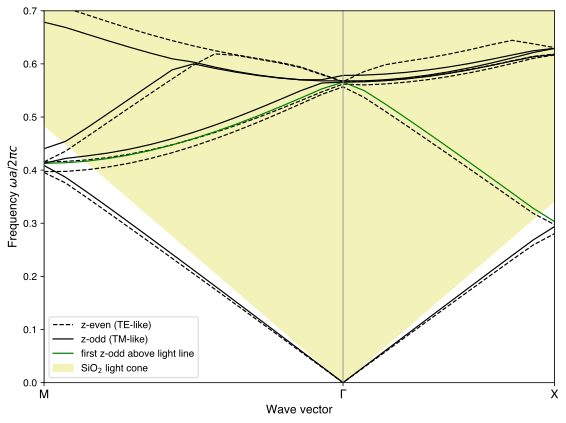

In [8]:
def plot_mpb_bands(even_freqs, odd_freqs, ymax=0.7):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    light_line = path["k_parallel"] / n_clad

    first_odd_above_ll = None
    first_crossing_idx = None
    for band_idx in range(odd_freqs.shape[1]):
        above = np.where(odd_freqs[:, band_idx] > light_line)[0]
        if len(above) == 0:
            continue
        crossing_idx = int(above[0])
        if first_crossing_idx is None or crossing_idx < first_crossing_idx:
            first_crossing_idx = crossing_idx
            first_odd_above_ll = band_idx

    for band_idx in range(even_freqs.shape[1]):
        ax.plot(
            path["path_x"],
            even_freqs[:, band_idx],
            linestyle="--",
            color="black",
            lw=1.2,
            label="z-even (TE-like)" if band_idx == 0 else None,
        )

    for band_idx in range(odd_freqs.shape[1]):
        odd_color = "green" if band_idx == 1 else "black"
        if band_idx == first_odd_above_ll == 0:
            odd_label = "z-odd (TM-like), first above light line"
        elif band_idx == 1:
            odd_label = "first z-odd above light line"
        elif band_idx == 0:
            odd_label = "z-odd (TM-like)"
        else:
            odd_label = None
        ax.plot(
            path["path_x"],
            odd_freqs[:, band_idx],
            linestyle="-",
            color=odd_color,
            lw=1.2,
            label=odd_label,
        )

    ax.fill_between(
        path["path_x"],
        light_line,
        ymax,
        color="#F0EFA6",
        alpha=0.8,
        label="SiO$_2$ light cone",
    )

    ax.set_xlim(path["path_x"][0], path["path_x"][-1])
    ax.set_ylim(0.0, ymax)
    ax.set_xticks(path["tick_locs"])
    ax.set_xticklabels(path["tick_labs"], size=12)
    ax.set_xlabel("Wave vector", size=12)
    ax.set_ylabel(r"Frequency $\omega a / 2\pi c$", size=12)
    for x in path["tick_locs"]:
        ax.axvline(x, color="#999999", lw=1)
    ax.legend(loc="lower left")
    fig.tight_layout()


plot_mpb_bands(mpb_even_freqs, mpb_odd_freqs)

Do convergence test with changing the height of supercell along z direction:
- Real guided modes don't depend on the supercell z height.
- Radiative continuum spectra depend on the supercell z height after supercell height discretization.


In [9]:
# Probe the band frequencies at a specific k point along G-X direction.
probe_k = mp.Vector3(0.35, 0.0, 0.0)
probe_light_line = np.sqrt(probe_k.x**2 + probe_k.y**2) / n_clad


def probe_mpb_supercell_dependence(k_point, supercell_z_values=(4.0, 6.0, 8.0), 
                                resolution=20, num_bands=6, mode_parity='even'):
    rows = []
    for supercell_z in supercell_z_values:
        ms = build_mpb_solver(
            supercell_z=supercell_z,
            resolution=resolution,
            num_bands=num_bands,
            k_points=[k_point],
        )
        if mode_parity.lower() == 'even':
            ms.run_zeven()
        elif mode_parity.lower() == 'odd':
            ms.run_zodd()

        freqs = np.array(ms.all_freqs)[0]
        rows.append((supercell_z, freqs))

    return rows

In [10]:
mpb_probe_rows = probe_mpb_supercell_dependence(k_point=probe_k, supercell_z_values=(1.0, 2.0,4.0, 6.0, 8.0))
mpb_probe_rows

Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 20 x 20 x 20.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
Geometric object tree has depth 1 and 10 object nodes (vs. 2 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
1 k-points
  Vector3<0.35, 0.0, 0.0>
elapsed time for initialization: 0.013567924499511719
solve_kpoint (0.35,0,0):
zevenfreqs:, k index, k1, k2, k3, kmag/2pi, zeven band 1, zeven band 2, zeven band 3, zeven band 4,

[(1.0,
  array([0.20261752, 0.37387356, 0.59147274, 0.59716658, 0.63460079,
         0.63584622])),
 (2.0,
  array([0.21667917, 0.37171523, 0.38167393, 0.39451153, 0.51468787,
         0.52404783])),
 (4.0,
  array([0.22364582, 0.27475225, 0.285637  , 0.39057021, 0.39921179,
         0.40124085])),
 (6.0,
  array([0.22525655, 0.25365644, 0.26224589, 0.31719591, 0.3221383 ,
         0.39364462])),
 (8.0,
  array([0.22566206, 0.24666996, 0.25304235, 0.28485153, 0.28988456,
         0.34069473]))]

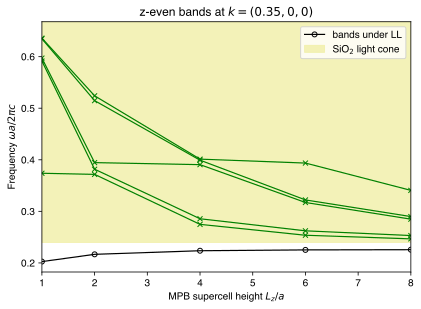

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

sz_values = [row[0] for row in mpb_probe_rows]
num_probe_bands = len(mpb_probe_rows[0][1])

for band_idx in range(num_probe_bands):
    band_values = [row[1][band_idx] for row in mpb_probe_rows]
    ax.plot(
        sz_values,
        band_values,
        lw=1.2,
        marker="o" if band_idx == 0 else "x",
        markerfacecolor="none",
        markersize=5,
        color = "black" if band_idx == 0 else "g",
        label = "bands under LL" if band_idx == 0 else None,
    )
ymin = np.min(mpb_probe_rows[0][1]*0.9)
ymax = np.max(band_values)*1.05
ax.fill_between(
        sz_values,
        probe_light_line,
        ymax,
        color="#F0EFA6",
        alpha=0.8,
        label="SiO$_2$ light cone",
    )
ax.set_xlim(np.min(sz_values), np.max(sz_values))
ax.set_ylim(ymin, ymax)

ax.set_xlabel("MPB supercell height $L_z / a$")
ax.set_ylabel(r"Frequency $\omega a / 2\pi c$")
ax.set_title(r"z-even bands at $k=(0.35, 0, 0)$")
ax.legend(loc="best")

fig.tight_layout()

From above：
- First band under LL is basically stable.
- Higher bands are slab guided modes, unstable when changing the z of supercell.

Hence, `MPB` can only obtain stable modes under LL;
if obtaining leaky modes above LL, `Meep` method with `run_k_points + Harminv` should be adopted.


## Meep FDTD attempt for the bands above the LL

Meep official tutorials on calculating `Band Diagram`:
- `x,y`: Bloch periodic boundary condition
- `z`: PML boundary condition, openning radiative channels
- At every k point, activate a wide-bandwidth pulse
- Fitting complex frequencies with `run_k_points` / `Harminv`
- Plotting band structures with `Re(ω)`, and `Im(ω)` for radiative loss


In [12]:
fdtd_path = build_mgx_path(nk_mg=13, nk_gx=9)
fdtd_path

{'k_points': [Vector3<0.5, 0.5, 0.0>,
  Vector3<0.4642857142857143, 0.4642857142857143, 0.0>,
  Vector3<0.4285714285714286, 0.4285714285714286, 0.0>,
  Vector3<0.39285714285714285, 0.39285714285714285, 0.0>,
  Vector3<0.35714285714285715, 0.35714285714285715, 0.0>,
  Vector3<0.32142857142857145, 0.32142857142857145, 0.0>,
  Vector3<0.2857142857142857, 0.2857142857142857, 0.0>,
  Vector3<0.25, 0.25, 0.0>,
  Vector3<0.2142857142857143, 0.2142857142857143, 0.0>,
  Vector3<0.1785714285714286, 0.1785714285714286, 0.0>,
  Vector3<0.1428571428571429, 0.1428571428571429, 0.0>,
  Vector3<0.10714285714285715, 0.10714285714285715, 0.0>,
  Vector3<0.07142857142857145, 0.07142857142857145, 0.0>,
  Vector3<0.035714285714285754, 0.035714285714285754, 0.0>,
  Vector3<0.0, 0.0, 0.0>,
  Vector3<0.05, 0.0, 0.0>,
  Vector3<0.1, 0.0, 0.0>,
  Vector3<0.15000000000000002, 0.0, 0.0>,
  Vector3<0.2, 0.0, 0.0>,
  Vector3<0.25, 0.0, 0.0>,
  Vector3<0.30000000000000004, 0.0, 0.0>,
  Vector3<0.35000000000000003, 0

In [13]:
def build_meep_sources(parity, fcen, df):
    """Construct a parity-selective broadband source set for one FDTD scan.

    The slab is mirror-symmetric about z = 0, so the z-even and z-odd sectors
    can be computed independently. 
    We combine a mirror constraint with sourcecomponents that transform with the same parity. 
    The source is placed away from symmetry planes so that it does not accidentally sit 
    on a field node for a mode that we want Harminv to detect.
    """
    src_center = mp.Vector3(0.173, 0.117, 0.09)
    gaussian = mp.GaussianSource(fcen, fwidth=df)

    if parity == "even":
        # Ex and Ey are even under z -> -z, so they preferentially excite the
        # z-even (roughly TE-like) subspace.
        symmetries = [mp.Mirror(mp.Z, phase=+1)]
        sources = [
            mp.Source(gaussian, component=mp.Ex, center=src_center),
            mp.Source(gaussian, component=mp.Ey, center=src_center),
        ]
    elif parity == "odd":
        # Ez is odd under z -> -z, which makes it a convenient probe for the
        # z-odd (roughly TM-like) subspace.
        symmetries = [mp.Mirror(mp.Z, phase=-1)]
        sources = [
            mp.Source(gaussian, component=mp.Ez, center=src_center),
        ]
    else:
        raise ValueError("parity must be 'even' or 'odd'")

    return symmetries, sources


def clean_harminv_modes(freqs, qmin=50, imag_max=5e-3, merge_tol=2e-3):
    """Convert raw Harminv fits into a compact list of plausible resonances.

    Harminv may report fits outside the frequency window of interest, strongly
    damped solutions, or multiple nearly identical fits of the same resonance.
    We keep only modes in the plotting range, discard low-Q / large-imaginary-
    part solutions, and merge near-duplicates by frequency.
    """
    cleaned = []
    for freq in sorted(freqs, key=lambda z: (np.real(z), abs(np.imag(z)))):
        freq_re = float(np.real(freq))
        freq_im = float(np.imag(freq))

        if not (0.05 <= freq_re <= 0.7):
            continue
        if abs(freq_im) > imag_max:
            continue

        q = np.inf if abs(freq_im) < 1e-12 else abs(freq_re / (2 * freq_im))
        if q < qmin:
            continue

        if any(abs(freq_re - old["freq"]) < merge_tol for old in cleaned):
            continue

        cleaned.append({"freq": freq_re, "freq_im": freq_im, "Q": q})
    return cleaned


def run_meep_window(
    k_points,
    parity,
    fcen,
    df,
    supercell_z=6.0,
    resolution=20,
    until_after_sources=250,
    qmin=50,
):
    """Run one broadband FDTD window and collect cleaned modes at each k point.

    A single wide pulse is usually not the most robust way to cover the entire
    spectrum. Instead, we scan several overlapping windows and merge the fitted
    resonances afterwards.
    """
    symmetries, sources = build_meep_sources(parity=parity, fcen=fcen, df=df)

    sim = mp.Simulation(
        cell_size=mp.Vector3(1, 1, supercell_z),
        geometry=[
            mp.Block(
                center=mp.Vector3(),
                size=mp.Vector3(mp.inf, mp.inf, slab_thickness),
                material=mp.Medium(index=n_slab),
            ),
            mp.Cylinder(
                center=mp.Vector3(),
                radius=hole_radius,
                height=slab_thickness,
                material=mp.Medium(index=n_clad),
            ),
        ],
        # The in-plane directions remain Bloch-periodic; only z is opened with
        # PML so that true radiative leakage can leave the simulation domain.
        boundary_layers=[mp.PML(1.0, direction=mp.Z)],
        sources=sources,
        resolution=resolution,
        default_material=mp.Medium(index=n_clad),
        symmetries=symmetries,
    )

    raw = sim.run_k_points(until_after_sources, k_points)
    return [clean_harminv_modes(freqs, qmin=qmin) for freqs in raw]


def merge_mode_sets(*mode_sets, merge_tol=2e-3):
    """Merge resonances found in several frequency windows at the same k points."""
    merged = []
    num_k = len(mode_sets[0])

    for k_idx in range(num_k):
        modes_here = []
        for mode_set in mode_sets:
            for mode in mode_set[k_idx]:
                if any(abs(mode["freq"] - old["freq"]) < merge_tol for old in modes_here):
                    continue
                modes_here.append(mode)
        merged.append(sorted(modes_here, key=lambda mode: mode["freq"]))
    return merged


def split_guided_and_radiative_modes(modes_by_k, light_line, light_line_tol=5e-4):
    """Track one below-light-line guided branch by continuity in frequency.

    Near Gamma, a true guided mode can sit arbitrarily close to the silica
    light line, so a fixed exclusion buffer is not reliable. We instead keep
    every mode that is numerically below the light line, split the path into
    contiguous guided segments, and use dynamic programming to retain the
    single branch with the smoothest frequency evolution along each segment.
    Any unselected modes are grouped with the radiative / leaky resonances.
    """
    guided_candidates_by_k = [
        [mode for mode in modes if mode["freq"] < ll + light_line_tol]
        for ll, modes in zip(light_line, modes_by_k)
    ]

    guided_branch = [[] for _ in modes_by_k]

    segments = []
    start = None
    for idx, guided_candidates in enumerate(guided_candidates_by_k):
        if guided_candidates and start is None:
            start = idx
        elif not guided_candidates and start is not None:
            segments.append((start, idx))
            start = None
    if start is not None:
        segments.append((start, len(guided_candidates_by_k)))

    for start, stop in segments:
        segment_candidates = guided_candidates_by_k[start:stop]
        costs = np.zeros(len(segment_candidates[0]), dtype=float)
        parents = []

        for prev_candidates, candidates_here in zip(segment_candidates[:-1], segment_candidates[1:]):
            next_costs = np.empty(len(candidates_here), dtype=float)
            next_parents = np.empty(len(candidates_here), dtype=int)

            for j, mode in enumerate(candidates_here):
                jumps = costs + np.array(
                    [abs(mode["freq"] - prev_mode["freq"])
                     for prev_mode in prev_candidates],
                    dtype=float,
                )
                parent = int(np.argmin(jumps))
                next_costs[j] = jumps[parent]
                next_parents[j] = parent

            parents.append(next_parents)
            costs = next_costs

        choice = int(np.argmin(costs))
        selected = [choice]
        for next_parents in reversed(parents):
            choice = int(next_parents[choice])
            selected.append(choice)
        selected.reverse()

        for idx, choice in zip(range(start, stop), selected):
            guided_branch[idx] = [guided_candidates_by_k[idx][choice]]

    radiative_modes = []
    for modes, guided_here in zip(modes_by_k, guided_branch):
        selected_mode = guided_here[0] if guided_here else None
        radiative_modes.append(
            [mode for mode in modes if mode is not selected_mode])

    return guided_branch, radiative_modes


def combine_mode_sets(guided_branch, radiative_modes):
    """Recombine the filtered guided branch with above-light-line resonances."""
    combined = []
    for guided_here, radiative_here in zip(guided_branch, radiative_modes):
        combined.append(sorted(guided_here + radiative_here,
                        key=lambda mode: mode["freq"]))
    return combined

In [14]:
light_line = fdtd_path["k_parallel"] / n_clad

# Low-frequency window: capture the fundamental z-even branch that remains
# below the light line over much of the path.
raw_meep_even_low = run_meep_window(
    fdtd_path["k_points"],
    parity="even",
    fcen=0.22,
    df=0.35,
    until_after_sources=250,
)

# Mid-frequency window: capture z-even resonances that live above the light line.
raw_meep_even_mid = run_meep_window(
    fdtd_path["k_points"],
    parity="even",
    fcen=0.42,
    df=0.30,
    until_after_sources=220,
)

# The odd sector is shifted lower in frequency, so one broader window is enough
# for this demonstration.
raw_meep_odd_mid = run_meep_window(
    fdtd_path["k_points"],
    parity="odd",
    fcen=0.26,
    df=0.45,
    until_after_sources=250,
)

raw_meep_even_modes = merge_mode_sets(raw_meep_even_low, raw_meep_even_mid)
raw_meep_odd_modes = merge_mode_sets(raw_meep_odd_mid)

# Track the single guided branch below the light line for each parity.
meep_even_guided, meep_even_radiative = split_guided_and_radiative_modes(
    raw_meep_even_modes, light_line)
meep_odd_guided, meep_odd_radiative = split_guided_and_radiative_modes(
    raw_meep_odd_modes, light_line)

# Store the guided frequencies as arrays so that the numerical values are easy
# to inspect and the plotting cell can draw only these branches.
meep_even_guided_freqs = np.array(
    [modes[0]["freq"] if modes else np.nan for modes in meep_even_guided],
    dtype=float,
)
meep_odd_guided_freqs = np.array(
    [modes[0]["freq"] if modes else np.nan for modes in meep_odd_guided],
    dtype=float,
)

meep_guided_table = [
    {
        "k_index": idx,
        "kx": float(k.x),
        "ky": float(k.y),
        "light_line": float(ll),
        "z_even_guided": None if np.isnan(even_freq) else float(even_freq),
        "z_odd_guided": None if np.isnan(odd_freq) else float(odd_freq),
    }
    for idx, (k, ll, even_freq, odd_freq) in enumerate(
        zip(
            fdtd_path["k_points"],
            light_line,
            meep_even_guided_freqs,
            meep_odd_guided_freqs,
        )
    )
]

meep_guided_table

-----------
Initializing structure...
Halving computational cell along direction z
time for choose_chunkdivision = 0.003629 s


Working in 3D dimensions.
Computational cell is 1 x 1 x 6 with resolution 20
     block, center = (0,0,0)
          size (1e+20,1e+20,0.535714)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.0804,4.0804,4.0804)
     cylinder, center = (0,0,0)
          radius 0.238095, height 0.535714, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (2.1316,2.1316,2.1316)
time for set_epsilon = 0.057768 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 230.025/278.5714282989502 = 82.6% done in 4.0s, 0.8s to go
on time step 9207 (time=230.175), 0.000434469 s/step
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
run 0 finished at t = 278.575 (11143 timesteps)
freqs:, 1, 0.5, 0.5, 0.0, 
freqs-im:, 1, 0.5, 0.5, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 238.32500000000002/278.5714282989502 = 85.6% done in 4.0s, 0.7s to go
on time step 9536 (time=238.4), 0.000419463 s/step
harminv1:, frequency, imag. freq., Q, |amp|, amplitude, error
run 1 finished at t = 278.575 (11143 timesteps)
freqs:, 2, 0.4642857142857143, 0.4642857142857143, 0.0, 
freqs-im:, 2, 0.4642857142857143, 0.4642857142857143, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 243.35000000000002/278.5714282989502 = 87.4% done in 4.0s, 0.6s to go
on time step 9737 (time=243.425), 0.000410845 s/step
harminv2:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv2:, 0.3703493796773618, 1.8238358766138074e-06, -101530.34722755986, 0.0021225598731551437, 0.0005651653501724942-0.002045934637786061i, 3.2433554598807276e-07+0.0i
run 2 finished at t = 278.575 (11143 timesteps)
freqs:, 3, 0.4285714285714286, 0.4285714285714286, 0.0, 0.3703493796773618
freqs-im:, 3, 0.4285714285714286, 0.4285714285714286, 0.0, 1.8238358766138074e-06


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 246.72500000000002/278.5714282989502 = 88.6% done in 4.0s, 0.5s to go
on time step 9871 (time=246.775), 0.000405237 s/step
harminv3:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv3:, 0.3429676069127294, -3.4337915606813426e-06, 49940.07365500613, 0.005949684301357067, 0.002177816613496206+0.005536773255588009i, 1.322620756026027e-07+0.0i
run 3 finished at t = 278.575 (11143 timesteps)
freqs:, 4, 0.39285714285714285, 0.39285714285714285, 0.0, 0.3429676069127294
freqs-im:, 4, 0.39285714285714285, 0.39285714285714285, 0.0, -3.4337915606813426e-06


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 248.0/278.5714282989502 = 89.0% done in 4.0s, 0.5s to go
on time step 9922 (time=248.05), 0.00040315 s/step
harminv4:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv4:, 0.31504592363568185, -3.020695291014421e-05, 5214.791517913777, 0.013059649913350515, -0.01110808468967341-0.006867671394753777i, 4.0912289448394684e-08+0.0i
run 4 finished at t = 278.575 (11143 timesteps)
freqs:, 5, 0.35714285714285715, 0.35714285714285715, 0.0, 0.31504592363568185
freqs-im:, 5, 0.35714285714285715, 0.35714285714285715, 0.0, -3.020695291014421e-05


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 246.425/278.5714282989502 = 88.5% done in 4.0s, 0.5s to go
on time step 9859 (time=246.475), 0.000405727 s/step
harminv5:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv5:, 0.28665731277037787, -0.00011039559273469866, 1298.3186451078225, 0.022401781263574845, 0.02235864393226028-0.0013895485926924526i, 1.2221902041959475e-07+0.0i
run 5 finished at t = 278.575 (11143 timesteps)
freqs:, 6, 0.32142857142857145, 0.32142857142857145, 0.0, 0.28665731277037787
freqs-im:, 6, 0.32142857142857145, 0.32142857142857145, 0.0, -0.00011039559273469866


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 241.97500000000002/278.5714282989502 = 86.9% done in 4.0s, 0.6s to go
on time step 9691 (time=242.275), 0.000412782 s/step
harminv6:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv6:, 0.2578957784946737, -0.00017003511727712434, 758.3603393949306, 0.029823394294363727, -0.024731869870701282+0.01666641712953882i, 5.418225787434813e-07+0.0i
run 6 finished at t = 278.575 (11143 timesteps)
freqs:, 7, 0.2857142857142857, 0.2857142857142857, 0.0, 0.2578957784946737
freqs-im:, 7, 0.2857142857142857, 0.2857142857142857, 0.0, -0.00017003511727712434


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 240.775/278.5714282989502 = 86.4% done in 4.0s, 0.6s to go
on time step 9632 (time=240.8), 0.00041529 s/step
harminv7:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv7:, 0.22857224008063384, 0.00018874374263071788, -605.5094513195106, 0.025923381028581154, 0.014359015203870172-0.02158333538469035i, 1.2065445331404252e-06+0.0i
run 7 finished at t = 278.575 (11143 timesteps)
freqs:, 8, 0.25, 0.25, 0.0, 0.22857224008063384
freqs-im:, 8, 0.25, 0.25, 0.0, 0.00018874374263071788


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 242.35000000000002/278.5714282989502 = 87.0% done in 4.0s, 0.6s to go
on time step 9696 (time=242.4), 0.000412547 s/step
harminv8:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv8:, 0.19789227628760697, 0.0007854813750775593, -125.96878969158682, 0.012474581601540155, -0.00010300391076140981+0.012474156337318047i, 6.254681126203533e-08+0.0i
run 8 finished at t = 278.575 (11143 timesteps)
freqs:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, 0.19789227628760697
freqs-im:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, 0.0007854813750775593


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 246.025/278.5714282989502 = 88.3% done in 4.0s, 0.5s to go
on time step 9843 (time=246.075), 0.000406401 s/step
harminv9:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv9:, 0.16636606181256894, 0.0010523878447209652, -79.04218138165592, 0.003752760161813807, -0.0015067388578553073-0.003436996777177086i, 1.1951241690731668e-06+0.0i
run 9 finished at t = 278.575 (11143 timesteps)
freqs:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, 0.16636606181256894
freqs-im:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, 0.0010523878447209652


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 244.10000000000002/278.5714282989502 = 87.6% done in 4.0s, 0.6s to go
on time step 9769 (time=244.225), 0.000409494 s/step
harminv10:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv10:, 0.13383323481633125, -0.00038352024885050215, 174.4800114432811, 0.0038495053597013434, 0.0037262632177703535-0.0009662577017861743i, 2.8377610460406867e-05+0.0i
run 10 finished at t = 278.575 (11143 timesteps)
freqs:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, 0.13383323481633125
freqs-im:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, -0.00038352024885050215


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 247.10000000000002/278.5714282989502 = 88.7% done in 4.0s, 0.5s to go
on time step 9886 (time=247.15), 0.000404646 s/step
harminv11:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv11:, 0.1009571977752096, -0.0009571374453465832, 52.73913285184063, 0.0012276298484048263, -0.001061583343337408+0.0006165353597670027i, 3.8060578565634796e-06+0.0i
run 11 finished at t = 278.575 (11143 timesteps)
freqs:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, 0.1009571977752096
freqs-im:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, -0.0009571374453465832


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 248.3/278.5714282989502 = 89.1% done in 4.0s, 0.5s to go
on time step 9934 (time=248.35), 0.000402687 s/step
harminv12:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv12:, 0.05999265188186078, 0.0005354172092423735, -56.02420957551181, 2.1739364247444025e-05, -2.1467375246276173e-05-3.4280837093945885e-06i, 0.0007322170945351661+0.0i
harminv12:, 0.06730037442535526, 0.00034670338273786534, -97.0575681925774, 4.975722002933611e-05, 2.041090333854896e-05-4.5378144188057956e-05i, 0.0003230376571218535+0.0i
run 12 finished at t = 278.575 (11143 timesteps)
freqs:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, 0.05999265188186078, 0.06730037442535526
freqs-im:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, 0.0005354172092423735, 0.00034670338273786534


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 245.425/278.5714282989502 = 88.1% done in 4.0s, 0.5s to go
on time step 9819 (time=245.475), 0.0004074 s/step
harminv13:, frequency, imag. freq., Q, |amp|, amplitude, error
run 13 finished at t = 278.575 (11143 timesteps)
freqs:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, 
freqs-im:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 249.125/278.5714282989502 = 89.4% done in 4.0s, 0.5s to go
on time step 9967 (time=249.175), 0.000401358 s/step
harminv14:, frequency, imag. freq., Q, |amp|, amplitude, error
run 14 finished at t = 278.575 (11143 timesteps)
freqs:, 15, 0.0, 0.0, 0.0, 
freqs-im:, 15, 0.0, 0.0, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 198.175/278.5714282989502 = 71.1% done in 4.0s, 1.6s to go
on time step 7929 (time=198.225), 0.000504496 s/step
harminv15:, frequency, imag. freq., Q, |amp|, amplitude, error
run 15 finished at t = 278.575 (11143 timesteps)
freqs:, 16, 0.05, 0.0, 0.0, 
freqs-im:, 16, 0.05, 0.0, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 247.175/278.5714282989502 = 88.7% done in 4.0s, 0.5s to go
on time step 9890 (time=247.25), 0.000404484 s/step
harminv16:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv16:, 0.053406135900638536, 0.00041097695377434435, -64.97461160554798, 9.893958293564784e-06, -9.214117881198665e-06-3.604225629198927e-06i, 0.0010994574726674196+0.0i
harminv16:, 0.0667726504210891, -0.0003491197501444661, 95.63001003732747, 7.628100222947544e-05, 2.1536429361901876e-05-7.317768451839023e-05i, 0.0001376458775992614+0.0i
run 16 finished at t = 278.575 (11143 timesteps)
freqs:, 17, 0.1, 0.0, 0.0, 0.053406135900638536, 0.0667726504210891
freqs-im:, 17, 0.1, 0.0, 0.0, 0.00041097695377434435, -0.0003491197501444661


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 249.0/278.5714282989502 = 89.4% done in 4.0s, 0.5s to go
on time step 9962 (time=249.05), 0.00040155 s/step
harminv17:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv17:, 0.10014700737426505, -0.0008843088921785991, 56.62444891147769, 0.001295359234769846, -0.00048171589306644856+0.0012024580431228005i, 6.126611162695025e-06+0.0i
run 17 finished at t = 278.575 (11143 timesteps)
freqs:, 18, 0.15000000000000002, 0.0, 0.0, 0.10014700737426505
freqs-im:, 18, 0.15000000000000002, 0.0, 0.0, -0.0008843088921785991


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 245.425/278.5714282989502 = 88.1% done in 4.0s, 0.5s to go
on time step 9819 (time=245.475), 0.000407376 s/step
harminv18:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv18:, 0.13261866685068513, 0.0006948600463252671, -95.42832945427814, 0.002246852715324448, 0.0015075963786278972-0.0016659832782800954i, 4.161517751063994e-06+0.0i
harminv18:, 0.13487524386859978, -0.0005564159483239287, 121.20001617034839, 0.0031136723402627464, 0.0027810209794273425-0.001400313448661504i, 1.3125847425862083e-05+0.0i
run 18 finished at t = 278.575 (11143 timesteps)
freqs:, 19, 0.2, 0.0, 0.0, 0.13261866685068513, 0.13487524386859978
freqs-im:, 19, 0.2, 0.0, 0.0, 0.0006948600463252671, -0.0005564159483239287


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 242.75/278.5714282989502 = 87.1% done in 4.0s, 0.6s to go
on time step 9712 (time=242.8), 0.000411895 s/step
harminv19:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv19:, 0.1645371089416303, 0.0007545690591467599, -109.02720363838073, 0.012286084135503366, -0.008931277298172047+0.008436832889646688i, 9.266814168671007e-07+0.0i
harminv19:, 0.16926015532643718, -0.0008295893383289714, 102.01442298389178, 0.0047689876178956874, -0.004441418974195816-0.0017369629804045248i, 4.46399205577356e-06+0.0i
run 19 finished at t = 278.575 (11143 timesteps)
freqs:, 20, 0.25, 0.0, 0.0, 0.1645371089416303, 0.16926015532643718
freqs-im:, 20, 0.25, 0.0, 0.0, 0.0007545690591467599, -0.0008295893383289714


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 246.25/278.5714282989502 = 88.4% done in 4.0s, 0.5s to go
on time step 9853 (time=246.325), 0.000405994 s/step
harminv20:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv20:, 0.19592176106396333, 0.0007862838872650097, -124.58716516845635, 0.03281316400507752, 0.0323288927750662-0.0056166203327612995i, 1.0138327443724949e-07+0.0i
harminv20:, 0.20365647912814833, -0.0016773167307149676, 60.709010826279176, 0.00946947726011918, 0.00385197813406877+0.008650622176154171i, 3.128908358239849e-06+0.0i
run 20 finished at t = 278.575 (11143 timesteps)
freqs:, 21, 0.30000000000000004, 0.0, 0.0, 0.19592176106396333, 0.20365647912814833
freqs-im:, 21, 0.30000000000000004, 0.0, 0.0, 0.0007862838872650097, -0.0016773167307149676


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 248.60000000000002/278.5714282989502 = 89.2% done in 4.0s, 0.5s to go
on time step 9947 (time=248.675), 0.000402182 s/step
harminv21:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv21:, 0.22625561389143672, 0.00029539190525297213, -382.97531155715416, 0.06955510223433238, -0.06534857451732888-0.02382175592565635i, 6.650591674946334e-07+0.0i
harminv21:, 0.23815163553712243, -0.0009768592237608897, 121.89659970668194, 0.002393167548620598, -9.893086172345269e-06-0.002393147100079038i, 2.18189353672268e-05+0.0i
run 21 finished at t = 278.575 (11143 timesteps)
freqs:, 22, 0.35000000000000003, 0.0, 0.0, 0.22625561389143672, 0.23815163553712243
freqs-im:, 22, 0.35000000000000003, 0.0, 0.0, 0.00029539190525297213, -0.0009768592237608897


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 243.32500000000002/278.5714282989502 = 87.3% done in 4.0s, 0.6s to go
on time step 9735 (time=243.375), 0.000410906 s/step
harminv22:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv22:, 0.25519193307229154, -0.00011506347090110966, 1108.918108735022, 0.09195196703482693, 0.06848276843580713+0.061361833976353065i, 1.1853938285129626e-07+0.0i
harminv22:, 0.2725831319995785, -0.0012313023027738354, 110.68895566324883, 0.0010651301798740222, -0.0003460178012519905+0.0010073599065354968i, 5.713441627997949e-07+0.0i
harminv22:, 0.3681361289471786, -0.000657883006839201, 279.7884465171769, 0.008028752633997776, 0.007222586336174882-0.003506439144549087i, 4.119216672527883e-07+0.0i
run 22 finished at t = 278.575 (11143 timesteps)
freqs:, 23, 0.4, 0.0, 0.0, 0.25519193307229154, 0.2725831319995785, 0.3681361289471786
freqs-im:, 23, 0.4, 0.0, 0.0, -0.00011506347090110966, -0.0012313023027738354, -0.000657883006839201


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 246.125/278.5714282989502 = 88.4% done in 4.0s, 0.5s to go
on time step 9850 (time=246.25), 0.000406131 s/step
harminv23:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv23:, 0.2831154249078021, -0.00010499713777544044, 1348.2054411488195, 0.07851149254716319, -0.03244837989266927-0.0714923569643936i, 5.20129768430007e-08+0.0i
harminv23:, 0.34095919856575835, -0.0006733299661336124, 253.1887898318341, 0.020905032255341995, -0.007353966616418392+0.019568841268748974i, 2.0935572128640948e-07+0.0i
run 23 finished at t = 278.575 (11143 timesteps)
freqs:, 24, 0.45, 0.0, 0.0, 0.2831154249078021, 0.34095919856575835
freqs-im:, 24, 0.45, 0.0, 0.0, -0.00010499713777544044, -0.0006733299661336124


FloatProgress(value=0.0, description='0% done ', max=278.5714282989502)

Meep progress: 249.35000000000002/278.5714282989502 = 89.5% done in 4.0s, 0.5s to go
on time step 9975 (time=249.375), 0.000401008 s/step
harminv24:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv24:, 0.30448712411232326, 1.2100951541517388e-05, -12581.123189678618, 0.04912865387061339, 0.03009199037253688+0.03883422133322212i, 1.0529713071520943e-08+0.0i
harminv24:, 0.31998990809913413, -2.379739948407422e-05, 6723.2116751512895, 0.045621268217854484, -0.040935501023218475+0.02013913776166942i, 1.0362941186632896e-08+0.0i
harminv24:, 0.3399468098036463, -0.000539753617171058, 314.9092465423078, 8.698745594920736e-05, -6.031744032276769e-05+6.267873551233025e-05i, 2.7358194958621066e-06+0.0i
run 24 finished at t = 278.575 (11143 timesteps)
freqs:, 25, 0.5, 0.0, 0.0, 0.30448712411232326, 0.31998990809913413, 0.3399468098036463
freqs-im:, 25, 0.5, 0.0, 0.0, 1.2100951541517388e-05, -2.379739948407422e-05, -0.000539753617171058
-----------
Initializing structure...
Halving comp

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 247.85000000000002/253.33333206176758 = 97.8% done in 4.0s, 0.1s to go
on time step 9916 (time=247.9), 0.000403406 s/step
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv0:, 0.41522719475055603, 7.456720064293722e-05, -2784.2482429966685, 0.31119989359748873, 0.26291715207000893+0.1664930777013991i, 1.4177814465577056e-06+0.0i
harminv0:, 0.4171535304689028, -1.816286033468935e-05, 11483.695926246233, 0.7225632709478815, -0.6946534745701061-0.19888245470775123i, 6.683488755877136e-07+0.0i
harminv0:, 0.4346462446284465, 6.445858955767203e-08, -3371515.32178316, 7.886315655912112, 0.3389594771590292+7.879027928464816i, 2.5310030177136305e-09+0.0i
harminv0:, 0.4846377986104242, -0.004296858636121121, 56.39443133366829, 0.0814969477933589, 0.05144661263528633+0.06320600088589899i, 2.3858163223745717e-06+0.0i
run 0 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 1, 0.5, 0.5, 0.0, 0.41522719475055603, 0.4171535304689028, 0.4346462446284465, 0.4

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 242.05/253.33333206176758 = 95.5% done in 4.0s, 0.2s to go
on time step 9685 (time=242.125), 0.000413045 s/step
harminv1:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv1:, 0.39686499473948156, -1.6136300323209118e-05, 12297.27343908764, 0.056742906088224174, -0.05123096217248929+0.024395612437854448i, 3.4033859890915396e-07+0.0i
harminv1:, 0.41727995580515964, -1.8269236178227004e-05, 11420.290146078123, 0.4738028280288653, -0.47330300247980817+0.02175747438810866i, 1.1765017677890601e-07+0.0i
harminv1:, 0.43526739536063086, 7.360535115589865e-07, -295676.46137487993, 7.699190802337569, 0.7037862942974904+7.666956623247481i, 6.901485598510678e-09+0.0i
harminv1:, 0.45273428328333815, 0.0005446961725722657, -415.5842340009036, 0.03869574121157275, 0.0056601455022073505+0.0382795394539544i, 8.337944564881825e-07+0.0i
harminv1:, 0.5427127965998807, -0.002319055504938514, 117.01160137050489, 3.9259243349895225e-05, -1.5684788700255632e-05+3.598993736914008e-05i, 

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 247.625/253.33333206176758 = 97.7% done in 4.0s, 0.1s to go
on time step 9907 (time=247.675), 0.00040377 s/step
harminv2:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv2:, 0.3703544263380023, -4.244982844447311e-05, 4362.260578066267, 0.029752417808657936, 0.024790167341550286-0.016451564321938488i, 8.038569740260158e-07+0.0i
harminv2:, 0.4201949390201468, -3.326994850851771e-05, 6314.932211460581, 0.4650935686891033, -0.39792062040968407+0.2407721069574666i, 5.747369085496565e-08+0.0i
harminv2:, 0.438004846608199, -0.0015522346634690475, 141.0884761551819, 6.792866274381938, 2.9306164824604983+6.128174218669571i, 1.0111608820491248e-08+0.0i
harminv2:, 0.47884041626602286, -0.0004480900704422435, 534.3126838242925, 0.04496485316015308, 0.03128478672603965-0.032297060844918096i, 5.195993551490688e-07+0.0i
run 2 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 3, 0.4285714285714286, 0.4285714285714286, 0.0, 0.3703544263380023, 0.4201949390201468, 0

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 247.32500000000002/253.33333206176758 = 97.6% done in 4.0s, 0.1s to go
on time step 9895 (time=247.375), 0.000404255 s/step
harminv3:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv3:, 0.3426985490550425, -9.459719929200182e-05, 1811.356740051064, 0.012062150311964321, -0.00652697870707084+0.01014366891740187i, 2.9192132108942468e-06+0.0i
harminv3:, 0.4251441756408712, -7.75107121909007e-05, 2742.486577815115, 0.4983671904163318, -0.16445031447898387+0.4704529206533122i, 2.2275397256419105e-08+0.0i
harminv3:, 0.44325655588271085, -0.0015483937925354504, 143.13431054153574, 6.580709695298417, 5.4343835965505365+3.7112282359532984i, 4.0866820395570135e-09+0.0i
run 3 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 4, 0.39285714285714285, 0.39285714285714285, 0.0, 0.3426985490550425, 0.4251441756408712, 0.44325655588271085
freqs-im:, 4, 0.39285714285714285, 0.39285714285714285, 0.0, -9.459719929200182e-05, -7.75107121909007e-05, -0.001548393792535450

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 244.65/253.33333206176758 = 96.6% done in 4.0s, 0.1s to go
on time step 9788 (time=244.7), 0.000408704 s/step
harminv4:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv4:, 0.315007543474117, -2.058780294770379e-05, 7650.343853452576, 0.003032663542595728, 0.001450655256772787-0.0026632024873424007i, 1.939960851020472e-06+0.0i
harminv4:, 0.4319586502516764, -0.0001262027628031717, 1711.3676462272365, 0.5354589208257824, 0.2612983122709944+0.4673750612690426i, 7.28966526076495e-09+0.0i
harminv4:, 0.44971439267397983, -0.0014180394769697769, 158.56906665073217, 6.204238617090543, 6.19415119223075-0.35364929744586354i, 1.5638630880219844e-09+0.0i
harminv4:, 0.5295662621309912, -0.0041159887493125965, 64.33038261091373, 0.007192436043754007, -0.003651283401127094-0.006196714110570662i, 8.736741838264944e-06+0.0i
run 4 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 5, 0.35714285714285715, 0.35714285714285715, 0.0, 0.315007543474117, 0.4319586502516764,

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 245.97500000000002/253.33333206176758 = 97.1% done in 4.0s, 0.1s to go
on time step 9841 (time=246.025), 0.000406491 s/step
harminv5:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv5:, 0.28660961957104125, 0.00016341047994232938, -876.9621742503638, 0.0004665310843659489, -0.00014097223232639546+0.00044472247794841776i, 1.4437381622948136e-05+0.0i
harminv5:, 0.4405347034007606, -0.0001742718542015448, 1263.9295812256744, 0.5534606849243842, 0.5525212601289093+0.03223331913611335i, 6.94687784045907e-09+0.0i
harminv5:, 0.45757528899037025, -0.001293537826567029, 176.86969781345604, 5.564233714180621, 3.623454438507104-4.222709409619307i, 1.2542488678763288e-09+0.0i
harminv5:, 0.5128882608374231, -0.0034381818299572754, 74.58713445120448, 0.01418171445318986, -0.014145623323822158+0.0010111209682094216i, 2.4971356957380365e-06+0.0i
harminv5:, 0.5593497808450673, -0.002168041367749759, 128.99887178481848, 0.0007496988631330693, -0.0007115488197138913-0.0002361073

FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 244.07500000000002/253.33333206176758 = 96.3% done in 4.0s, 0.2s to go
on time step 9765 (time=244.125), 0.000409633 s/step
harminv6:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv6:, 0.4507528756082096, -0.000222103104008129, 1014.7379020684734, 0.537410925435169, 0.24712162522955866-0.47722259493970565i, 5.189337352218613e-09+0.0i
harminv6:, 0.46681548381277677, -0.0011821223672314797, 197.44803784825365, 4.684332428138727, -1.1162732516680625-4.549385049094269i, 4.2687867568994387e-10+0.0i
harminv6:, 0.5269388851040665, -0.002416236642955127, 109.0412411881158, 0.003676205738583674, -0.0034522352462933686+0.0012635507257903428i, 2.4289036342082227e-06+0.0i
run 6 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 7, 0.2857142857142857, 0.2857142857142857, 0.0, 0.4507528756082096, 0.46681548381277677, 0.5269388851040665
freqs-im:, 7, 0.2857142857142857, 0.2857142857142857, 0.0, -0.000222103104008129, -0.0011821223672314797, -0.002416236642955127


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 242.57500000000002/253.33333206176758 = 95.8% done in 4.0s, 0.2s to go
on time step 9704 (time=242.6), 0.000412202 s/step
harminv7:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv7:, 0.4624771867048919, -0.00026874917322578076, 860.4253199252764, 0.47957919190856074, -0.34886090755252575-0.3290779064192797i, 2.7263036012671475e-09+0.0i
harminv7:, 0.4773530784148756, -0.0010814216147968642, 220.7062776827067, 3.652725881408405, -3.5446818859181843-0.8818371121439116i, 1.230196278019725e-09+0.0i
harminv7:, 0.5411523056690924, -0.003229403080424476, 83.78519066718094, 0.002861840531204319, 0.0010777393636071295+0.0026511524079493275i, 3.9486798975286555e-06+0.0i
run 7 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 8, 0.25, 0.25, 0.0, 0.4624771867048919, 0.4773530784148756, 0.5411523056690924
freqs-im:, 8, 0.25, 0.25, 0.0, -0.00026874917322578076, -0.0010814216147968642, -0.003229403080424476


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 245.07500000000002/253.33333206176758 = 96.7% done in 4.0s, 0.1s to go
on time step 9805 (time=245.125), 0.000407989 s/step
harminv8:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv8:, 0.47556673431527846, -0.0003129610850553536, 759.7857321960088, 0.3852944503559576, -0.30266880484793224+0.23841855642341223i, 2.597356822932726e-09+0.0i
harminv8:, 0.4890856282286267, -0.0009882047735572815, 247.461680673756, 2.601421440250051, -1.4743618161128902+2.1432803701291507i, 1.411574975606083e-10+0.0i
harminv8:, 0.5575330416167026, -0.003414818295225611, 81.63436432272414, 0.001201819402020792, 0.0011238053478886047-0.00042594766712659174i, 6.410681468994363e-06+0.0i
run 8 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, 0.47556673431527846, 0.4890856282286267, 0.5575330416167026
freqs-im:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, -0.0003129610850553536, -0.0009882047735572815, -0.003414818295225611


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 245.57500000000002/253.33333206176758 = 96.9% done in 4.0s, 0.1s to go
on time step 9824 (time=245.6), 0.000407168 s/step
harminv9:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv9:, 0.4898774325716927, -0.00035300045486535297, 693.876489137315, 0.2732754715844441, 0.16326560917529515+0.2191433873752984i, 1.1815376260780024e-09+0.0i
harminv9:, 0.5019028087053375, -0.0008996070316062253, 278.9566950189367, 1.6688950683627386, 1.1050053392731285+1.2506694005145198i, 5.587608279609187e-10+0.0i
run 9 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, 0.4898774325716927, 0.5019028087053375
freqs-im:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, -0.00035300045486535297, -0.0008996070316062253


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 244.8/253.33333206176758 = 96.6% done in 4.0s, 0.1s to go
on time step 9797 (time=244.925), 0.000408305 s/step
harminv10:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv10:, 0.5052621051838901, -0.00038612104680515834, 654.2794149199175, 0.167968156201394, 0.12588482861244663-0.11120391819945386i, 6.759649274226082e-09+0.0i
harminv10:, 0.5156910806856878, -0.0008125958687241149, 317.3109171077822, 0.9520863725883602, 0.795704354102782-0.522803062089671i, 8.597359064355656e-10+0.0i
run 10 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, 0.5052621051838901, 0.5156910806856878
freqs-im:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, -0.00038612104680515834, -0.0008125958687241149


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 245.125/253.33333206176758 = 96.8% done in 4.0s, 0.1s to go
on time step 9807 (time=245.175), 0.0004079 s/step
harminv11:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv11:, 0.521561123965475, -0.0004070985219714883, 640.5834163185727, 0.08787834123918249, -0.06930829217603252-0.054027432796607246i, 2.4678157168074458e-09+0.0i
harminv11:, 0.5303311761008829, -0.0007226743778367214, 366.9226365049738, 0.47779253030871993, -0.24106119165680207-0.4125229737794146i, 5.556929090746335e-10+0.0i
run 11 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, 0.521561123965475, 0.5303311761008829
freqs-im:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, -0.0004070985219714883, -0.0007226743778367214


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 244.75/253.33333206176758 = 96.6% done in 4.0s, 0.1s to go
on time step 9792 (time=244.8), 0.000408501 s/step
harminv12:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv12:, 0.5385573636394259, -0.0004023738937489726, 669.2250317504613, 0.03836100423899225, -0.014057062353520802+0.03569265532589596i, 8.399311485151305e-09+0.0i
harminv12:, 0.5456761571912805, -0.0006191448034751758, 440.6692538873574, 0.20968618014737855, -0.1785880852451549+0.10988443908610614i, 1.8549587341887273e-09+0.0i
run 12 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, 0.5385573636394259, 0.5456761571912805
freqs-im:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, -0.0004023738937489726, -0.0006191448034751758


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 246.0/253.33333206176758 = 97.1% done in 4.0s, 0.1s to go
on time step 9842 (time=246.05), 0.000406443 s/step
harminv13:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv13:, 0.5556942505703497, -0.0003197984185267646, 868.8195725455761, 0.0134395244965075, 0.013414549174758605-0.000818956122272975i, 3.645543098482615e-08+0.0i
harminv13:, 0.5613979509157638, -0.00045725808206576715, 613.8742790280722, 0.08179929017213398, 0.04755597183634107+0.06655489024381386i, 7.213976950945319e-09+0.0i
run 13 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, 0.5556942505703497, 0.5613979509157638
freqs-im:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, -0.0003197984185267646, -0.00045725808206576715


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 252.35000000000002/253.33333206176758 = 99.6% done in 4.0s, 0.0s to go
on time step 10096 (time=252.4), 0.000396214 s/step
harminv14:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv14:, 0.567518214623151, -2.6985258497272957e-06, 105153.37747839298, 0.00428504691238699, -0.004234290636680835-0.0006575787751093345i, 3.3863729194069434e-07+0.0i
run 14 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 15, 0.0, 0.0, 0.0, 0.567518214623151
freqs-im:, 15, 0.0, 0.0, 0.0, -2.6985258497272957e-06


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 246.65/253.33333206176758 = 97.4% done in 4.0s, 0.1s to go
on time step 9869 (time=246.725), 0.000405319 s/step
harminv15:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv15:, 0.5508836751214169, -0.0004261854303419905, 646.2957622452777, 0.012486327447280584, 0.008498589733897959-0.00914780551037224i, 9.568374073199326e-08+0.0i
run 15 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 16, 0.05, 0.0, 0.0, 0.5508836751214169
freqs-im:, 16, 0.05, 0.0, 0.0, -0.0004261854303419905


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 247.3/253.33333206176758 = 97.6% done in 4.0s, 0.1s to go
on time step 9894 (time=247.35), 0.000404288 s/step
harminv16:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv16:, 0.5259799165084584, -0.0005363757308205812, 490.3092051758022, 0.03591763689122185, -0.02429874220778655+0.026450855694460877i, 6.698462430759923e-09+0.0i
run 16 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 17, 0.1, 0.0, 0.0, 0.5259799165084584
freqs-im:, 17, 0.1, 0.0, 0.0, -0.0005363757308205812


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 246.525/253.33333206176758 = 97.3% done in 4.0s, 0.1s to go
on time step 9862 (time=246.55), 0.000405598 s/step
harminv17:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv17:, 0.500398982233818, -0.0005807289246612734, 430.8369714197462, 0.09176865176628259, 0.03879414261806721-0.08316549732629692i, 2.699163241025494e-09+0.0i
run 17 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 18, 0.15000000000000002, 0.0, 0.0, 0.500398982233818
freqs-im:, 18, 0.15000000000000002, 0.0, 0.0, -0.0005807289246612734


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 248.32500000000002/253.33333206176758 = 98.0% done in 4.0s, 0.1s to go
on time step 9935 (time=248.375), 0.00040265 s/step
harminv18:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv18:, 0.47449106620118003, -0.0006058635183915802, 391.5824701418217, 0.174775145216085, -0.013276997998726142+0.1742701142176863i, 2.067212083498731e-09+0.0i
harminv18:, 0.5490442603842381, -0.005448919690485219, 50.381019685697225, 0.0016268079129096032, 0.0008882336595252831+0.00136291780808368i, 2.1779207962219175e-06+0.0i
run 18 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 19, 0.2, 0.0, 0.0, 0.47449106620118003, 0.5490442603842381
freqs-im:, 19, 0.2, 0.0, 0.0, -0.0006058635183915802, -0.005448919690485219


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 248.35000000000002/253.33333206176758 = 98.0% done in 4.0s, 0.1s to go
on time step 9936 (time=248.4), 0.000402593 s/step
harminv19:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv19:, 0.4483123485323682, -0.0006222268041805396, 360.24834153744524, 0.24418418284617596, -0.06942547472456098-0.2341068529785577i, 2.462585205185889e-09+0.0i
run 19 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 20, 0.25, 0.0, 0.0, 0.4483123485323682
freqs-im:, 20, 0.25, 0.0, 0.0, -0.0006222268041805396


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 245.775/253.33333206176758 = 97.0% done in 4.0s, 0.1s to go
on time step 9834 (time=245.85), 0.000406778 s/step
harminv20:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv20:, 0.42186958528907337, -0.0006337252478919856, 332.8489646675544, 0.2476278859688418, 0.14812114188279957+0.1984431839009173i, 6.1630152195324245e-09+0.0i
run 20 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 21, 0.30000000000000004, 0.0, 0.0, 0.42186958528907337
freqs-im:, 21, 0.30000000000000004, 0.0, 0.0, -0.0006337252478919856


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 247.55/253.33333206176758 = 97.7% done in 4.0s, 0.1s to go
on time step 9904 (time=247.6), 0.000403896 s/step
harminv21:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv21:, 0.3951538547388728, -0.0006476722773559388, 305.0569466644854, 0.18057834697504557, -0.14981086760357407-0.10082283146244382i, 2.82397033181567e-08+0.0i
run 21 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 22, 0.35000000000000003, 0.0, 0.0, 0.3951538547388728
freqs-im:, 22, 0.35000000000000003, 0.0, 0.0, -0.0006476722773559388


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 246.425/253.33333206176758 = 97.3% done in 4.0s, 0.1s to go
on time step 9859 (time=246.475), 0.00040574 s/step
harminv22:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv22:, 0.3681654887583634, -0.0006619384255423106, 278.09647737003183, 0.0928931199365279, 0.0895465010456493+0.024709429010474647i, 5.481127106785795e-08+0.0i
harminv22:, 0.4112208761749648, -0.003845084416813743, 53.47358231938714, 0.007123159965003626, 0.001960251909180593+0.006848125315703875i, 5.216742101442213e-06+0.0i
run 22 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 23, 0.4, 0.0, 0.0, 0.3681654887583634, 0.4112208761749648
freqs-im:, 23, 0.4, 0.0, 0.0, -0.0006619384255423106, -0.003845084416813743


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 246.95000000000002/253.33333206176758 = 97.5% done in 4.0s, 0.1s to go
on time step 9882 (time=247.05), 0.000404808 s/step
harminv23:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv23:, 0.28304529314152654, -7.065959123938979e-05, 2002.879497155515, 0.001457877098904559, 0.0014571692000453697-4.5426401458958885e-05i, 7.365176666665306e-07+0.0i
harminv23:, 0.3409837652928368, -0.0006686735503770479, 254.9702804160302, 0.03388086170769084, -0.03375234998802131+0.0029481621973340634i, 2.1636622721548063e-08+0.0i
run 23 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 24, 0.45, 0.0, 0.0, 0.28304529314152654, 0.3409837652928368
freqs-im:, 24, 0.45, 0.0, 0.0, -7.065959123938979e-05, -0.0006686735503770479


FloatProgress(value=0.0, description='0% done ', max=253.33333206176758)

Meep progress: 252.05/253.33333206176758 = 99.5% done in 4.0s, 0.0s to go
on time step 10084 (time=252.1), 0.0003967 s/step
harminv24:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv24:, 0.30447585003439814, -1.9766754018107853e-05, 7701.715965997125, 0.005199577311896208, -0.004471385121064452+0.0026537368598844213i, 5.58306053751097e-07+0.0i
harminv24:, 0.3199747296792776, -1.642544662105987e-05, 9740.213982036334, 0.015470515399515926, -0.008368059541053626-0.013012010845524252i, 1.090012783224734e-07+0.0i
harminv24:, 0.3396899590749789, 0.00030228465975372013, -561.8709850373054, 3.8462088716162995e-05, -3.8005133116674374e-05-5.911186445533048e-06i, 3.06790116203757e-05+0.0i
run 24 finished at t = 253.35000000000002 (10134 timesteps)
freqs:, 25, 0.5, 0.0, 0.0, 0.30447585003439814, 0.3199747296792776, 0.3396899590749789
freqs-im:, 25, 0.5, 0.0, 0.0, -1.9766754018107853e-05, -1.642544662105987e-05, 0.00030228465975372013
-----------
Initializing structure...
Halving comp

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 246.45000000000002/272.2222213745117 = 90.5% done in 4.0s, 0.4s to go
on time step 9860 (time=246.5), 0.000405712 s/step
harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv0:, 0.4337217768059771, 1.3938581592833481e-05, -15558.31825201551, 0.012018189201805564, -0.005389899593426586-0.010741780767785935i, 1.5120232208895223e-07+0.0i
harminv0:, 0.43803954497143505, -2.4572868772899727e-06, 89130.7297124641, 0.11035186137820951, -0.07732839275740026-0.07872644398925188i, 1.6996745425062876e-08+0.0i
harminv0:, 0.4610354729269641, 2.6890576515016656e-05, -8572.43563873585, 0.12871578356422156, -0.08862286096770379+0.0933474233841008i, 4.320097739021373e-09+0.0i
harminv0:, 0.48411245407646397, -0.0022510136536277904, 107.53210077074746, 0.001039397202606879, 0.0003733086645898823-0.0009700449400564515i, 2.090524158785235e-06+0.0i
run 0 finished at t = 272.225 (10889 timesteps)
freqs:, 1, 0.5, 0.5, 0.0, 0.4337217768059771, 0.43803954497143505, 0.4610354729269

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 245.425/272.2222213745117 = 90.2% done in 4.0s, 0.4s to go
on time step 9819 (time=245.475), 0.000407411 s/step
harminv1:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv1:, 0.41255267027957016, -7.412253486376322e-06, 27829.098872417107, 0.1243161362350497, 0.1048494589177093-0.06679141182124408i, 3.33823393064367e-09+0.0i
harminv1:, 0.43896574436146474, -1.4556331829040505e-05, 15078.171805815435, 0.004950409833793939, -0.0036826434353967753-0.003308276719117185i, 2.705950459372041e-07+0.0i
harminv1:, 0.44554641229524317, -1.0080796444367483e-05, 22098.770407381184, 0.11251127622553654, -0.10802025821762126-0.031470797455695504i, 2.216237474502625e-08+0.0i
harminv1:, 0.4489195092439961, -0.002403996095696722, 93.36943392869593, 0.003825708439451255, 0.00013395922731741523+0.003823362393117487i, 2.4293317109552467e-06+0.0i
harminv1:, 0.4751095044043723, -0.00037818261437760854, 628.1482626935145, 0.051075339221370336, 0.013072296089684632+0.049374136463554145

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 245.45000000000002/272.2222213745117 = 90.2% done in 4.0s, 0.4s to go
on time step 9820 (time=245.5), 0.000407358 s/step
harminv2:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv2:, 0.38538723200251224, -1.546913237081635e-05, 12456.653119394514, 0.2778090012577256, 0.06502321041990898+0.27009224958614275i, 9.7314680316268e-10+0.0i
harminv2:, 0.4441376377835559, 0.000622247744746956, -356.8816773809035, 0.0020269398684003726, 0.001169871313434827-0.001655260203144265i, 2.8901243563832e-05+0.0i
harminv2:, 0.4498007134975834, -0.0003956595718897823, 568.418844701782, 0.11798988025223833, -0.11770696941251008+0.008165855353847505i, 5.5123130941151754e-09+0.0i
run 2 finished at t = 272.225 (10889 timesteps)
freqs:, 3, 0.4285714285714286, 0.4285714285714286, 0.0, 0.38538723200251224, 0.4441376377835559, 0.4498007134975834
freqs-im:, 3, 0.4285714285714286, 0.4285714285714286, 0.0, -1.546913237081635e-05, 0.000622247744746956, -0.0003956595718897823


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 245.47500000000002/272.2222213745117 = 90.2% done in 4.0s, 0.4s to go
on time step 9821 (time=245.525), 0.000407324 s/step
harminv3:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv3:, 0.35694997713330384, 7.799993667285514e-06, -22881.42736771775, 0.4679868849642059, -0.4592340341031347-0.09008788164820937i, 1.122378000016796e-08+0.0i
harminv3:, 0.38036028144859557, -0.002670105528291573, 71.22570202159076, 0.007777438717079923, 0.007375715128403697-0.002467261506725751i, 4.811617281901567e-06+0.0i
harminv3:, 0.44644091753681364, -0.00012138014948339474, 1839.0194749178836, 0.004000490222678913, -0.003939539380190132-0.0006956662228976862i, 8.230142751028148e-07+0.0i
harminv3:, 0.45517451223108096, -0.0003541478629513877, 642.6334306209843, 0.10616701070389566, -0.0960388177988349+0.045254609020554865i, 3.1961853862291116e-08+0.0i
run 3 finished at t = 272.225 (10889 timesteps)
freqs:, 4, 0.39285714285714285, 0.39285714285714285, 0.0, 0.35694997713330384, 0.3

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 245.9/272.2222213745117 = 90.3% done in 4.0s, 0.4s to go
on time step 9838 (time=245.95), 0.000406627 s/step
harminv4:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv4:, 0.3276558175995984, 0.00012338613961764336, -1327.765900671496, 0.620330740064045, 0.3962243352513184-0.4773012709212669i, 6.683718968455782e-10+0.0i
harminv4:, 0.3441399094109113, -0.0022776860354895368, 75.54594971579266, 0.018690975647079403, 0.01441307965931707+0.011900239719177752i, 6.3947031240274784e-06+0.0i
harminv4:, 0.4529263978695032, -9.446006315313996e-05, 2397.4491586736112, 0.0031485425563686823, -0.003058166125542686+0.0007489593966617107i, 1.130828588543725e-07+0.0i
harminv4:, 0.4621223163146689, -0.00026661874814839766, 866.6350725970997, 0.08654787947979181, -0.05252751360701821+0.06878514197639694i, 2.411355727905419e-09+0.0i
run 4 finished at t = 272.225 (10889 timesteps)
freqs:, 5, 0.35714285714285715, 0.35714285714285715, 0.0, 0.3276558175995984, 0.3441399094109113, 0.4

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 242.3/272.2222213745117 = 89.0% done in 4.0s, 0.5s to go
on time step 9694 (time=242.35), 0.000412653 s/step
harminv5:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv5:, 0.2974471963143988, 0.0003164449243135172, -469.98256799294336, 0.6358586082702822, 0.22528729825266727+0.5946106313861483i, 3.451856294081987e-08+0.0i
harminv5:, 0.3097696806773557, -0.0008962330358068827, 172.8175978240239, 0.01535265016667558, -0.015337423246808814-0.0006836046288406273i, 2.866953840718362e-06+0.0i
harminv5:, 0.46089242674599284, -0.00023334550053907214, 987.5751314708112, 0.002678614544382068, -0.0016683753986261572+0.002095590467298934i, 4.903456704392293e-06+0.0i
harminv5:, 0.4706867957674633, -0.0001878094292539176, 1253.0968163773518, 0.06526837565945871, -0.0036182297496332727+0.06516800806149511i, 1.9872501044404396e-07+0.0i
run 5 finished at t = 272.225 (10889 timesteps)
freqs:, 6, 0.32142857142857145, 0.32142857142857145, 0.0, 0.2974471963143988, 0.309769680677355

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 247.32500000000002/272.2222213745117 = 90.9% done in 4.0s, 0.4s to go
on time step 9895 (time=247.375), 0.000404267 s/step
harminv6:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv6:, 0.26630693890930424, 0.00040264408104204104, -330.69769487248277, 0.5115987590333009, -0.5067313353202331-0.07040343776398293i, 2.670379965256475e-11+0.0i
harminv6:, 0.27497225375403467, -0.0010742265055733928, 127.98616135768405, 0.03838580611195374, 0.02047285481184109-0.03247048393106854i, 6.422501664589344e-09+0.0i
harminv6:, 0.47061119889436553, -0.00010132299540862658, 2322.331653325253, 0.001698460917411269, -0.00016265988810526826+0.0016906540890362853i, 1.3710222308528562e-07+0.0i
harminv6:, 0.48080530487954026, -0.00011124520451324196, 2161.0158702270537, 0.044944224194599786, 0.02689281685150804+0.03601054970763004i, 5.085589227750449e-09+0.0i
run 6 finished at t = 272.225 (10889 timesteps)
freqs:, 7, 0.2857142857142857, 0.2857142857142857, 0.0, 0.26630693890930424, 0

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 246.625/272.2222213745117 = 90.6% done in 4.0s, 0.4s to go
on time step 9867 (time=246.675), 0.000405415 s/step
harminv7:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv7:, 0.2343312179342459, 0.00023517091734129213, -498.21470397670896, 0.33191125036389, 0.18495756808252165-0.27560075494657166i, 5.785038207078786e-10+0.0i
harminv7:, 0.24034268506229553, -0.0005796464948963396, 207.31832865242887, 0.048126044209395216, 0.02668746335289901+0.040048663286461075i, 1.3237368248784497e-08+0.0i
harminv7:, 0.48160500403009293, -0.00011167241310905614, 2156.3293503820455, 0.0011294245350549122, 0.000698565758108259+0.0008874714992508989i, 2.558904929332997e-07+0.0i
run 7 finished at t = 272.225 (10889 timesteps)
freqs:, 8, 0.25, 0.25, 0.0, 0.2343312179342459, 0.24034268506229553, 0.48160500403009293
freqs-im:, 8, 0.25, 0.25, 0.0, 0.00023517091734129213, -0.0005796464948963396, -0.00011167241310905614


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 243.75/272.2222213745117 = 89.5% done in 4.0s, 0.5s to go
on time step 9752 (time=243.8), 0.000410215 s/step
harminv8:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv8:, 0.20161032856926814, -0.00013235480025705672, 761.6283209135777, 0.16290615134348252, 0.0888607679036113+0.13653636172509562i, 1.3823897188527171e-08+0.0i
harminv8:, 0.2059394271127612, -2.5499653741875552e-05, 4038.0828147200937, 0.04360904026133142, -0.04050336800664416+0.016162474211356956i, 5.4637804035583066e-08+0.0i
run 8 finished at t = 272.225 (10889 timesteps)
freqs:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, 0.20161032856926814, 0.2059394271127612
freqs-im:, 9, 0.2142857142857143, 0.2142857142857143, 0.0, -0.00013235480025705672, -2.5499653741875552e-05


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 244.45000000000002/272.2222213745117 = 89.8% done in 4.0s, 0.5s to go
on time step 9780 (time=244.5), 0.000409024 s/step
harminv9:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv9:, 0.16824269523195298, -0.00043177047401337575, 194.8288562533123, 0.05486840180721205, -0.05443637132887582+0.006871898822190058i, 1.2300494907791664e-08+0.0i
harminv9:, 0.17181111491045803, 0.00036432758722775954, -235.79207413004693, 0.02274002836076499, -0.006541319150844221-0.021778889632283704i, 1.7011440127878563e-08+0.0i
run 9 finished at t = 272.225 (10889 timesteps)
freqs:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, 0.16824269523195298, 0.17181111491045803
freqs-im:, 10, 0.1785714285714286, 0.1785714285714286, 0.0, -0.00043177047401337575, 0.00036432758722775954


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 244.775/272.2222213745117 = 89.9% done in 4.0s, 0.4s to go
on time step 9796 (time=244.9), 0.000408361 s/step
harminv10:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv10:, 0.13457358554901927, -0.00047288091669912976, 142.29119932391103, 0.013790791501056115, 0.006217987696947499-0.012309449996901206i, 4.3114103182698496e-07+0.0i
harminv10:, 0.1377210550026909, 0.0004466674817844486, -154.16507874324273, 0.00709140191042065, 0.007067690386992694-0.0005794252744994032i, 2.7463142974899006e-07+0.0i
run 10 finished at t = 272.225 (10889 timesteps)
freqs:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, 0.13457358554901927, 0.1377210550026909
freqs-im:, 11, 0.1428571428571429, 0.1428571428571429, 0.0, -0.00047288091669912976, 0.0004466674817844486


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 244.22500000000002/272.2222213745117 = 89.7% done in 4.0s, 0.5s to go
on time step 9772 (time=244.3), 0.000409372 s/step
harminv11:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv11:, 0.10136094716826717, -0.000261852829144868, 193.54564069305897, 0.0034387756863281543, 0.00011293499149563611+0.0034369207015259385i, 3.906474674385262e-07+0.0i
harminv11:, 0.10315974852616912, 0.0006905904103663435, -74.68953157881607, 0.0011498115178132492, 0.00048070307789576614+0.001044505183040058i, 3.940492796849245e-07+0.0i
run 11 finished at t = 272.225 (10889 timesteps)
freqs:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, 0.10136094716826717, 0.10315974852616912
freqs-im:, 12, 0.10714285714285715, 0.10714285714285715, 0.0, -0.000261852829144868, 0.0006905904103663435


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 201.175/272.2222213745117 = 73.9% done in 4.0s, 1.4s to go
on time step 8048 (time=201.2), 0.000497023 s/step
harminv12:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv12:, 0.06837802769785038, -0.0005652313893364859, 60.486757271316804, 0.0006278051496317478, -0.0004890492240492736-0.00039366249803727134i, 2.492545299562178e-05+0.0i
run 12 finished at t = 272.225 (10889 timesteps)
freqs:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, 0.06837802769785038
freqs-im:, 13, 0.07142857142857145, 0.07142857142857145, 0.0, -0.0005652313893364859


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 228.375/272.2222213745117 = 83.9% done in 4.0s, 0.8s to go
on time step 9138 (time=228.45), 0.00043776 s/step
harminv13:, frequency, imag. freq., Q, |amp|, amplitude, error
run 13 finished at t = 272.225 (10889 timesteps)
freqs:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, 
freqs-im:, 14, 0.035714285714285754, 0.035714285714285754, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 250.75/272.2222213745117 = 92.1% done in 4.0s, 0.3s to go
on time step 10032 (time=250.8), 0.000398743 s/step
harminv14:, frequency, imag. freq., Q, |amp|, amplitude, error
run 14 finished at t = 272.225 (10889 timesteps)
freqs:, 15, 0.0, 0.0, 0.0, 
freqs-im:, 15, 0.0, 0.0, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 243.8/272.2222213745117 = 89.6% done in 4.0s, 0.5s to go
on time step 9754 (time=243.85), 0.000410113 s/step
harminv15:, frequency, imag. freq., Q, |amp|, amplitude, error
run 15 finished at t = 272.225 (10889 timesteps)
freqs:, 16, 0.05, 0.0, 0.0, 
freqs-im:, 16, 0.05, 0.0, 0.0, 


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 243.375/272.2222213745117 = 89.4% done in 4.0s, 0.5s to go
on time step 9737 (time=243.425), 0.000410811 s/step
harminv16:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv16:, 0.06772849772064815, -0.0005319610926502591, 63.659258784529804, 0.0005826043100927135, -0.00042798437197205067-0.00039529376353073935i, 3.5040646724539654e-05+0.0i
run 16 finished at t = 272.225 (10889 timesteps)
freqs:, 17, 0.1, 0.0, 0.0, 0.06772849772064815
freqs-im:, 17, 0.1, 0.0, 0.0, -0.0005319610926502591


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 242.275/272.2222213745117 = 89.0% done in 4.0s, 0.5s to go
on time step 9693 (time=242.325), 0.000412691 s/step
harminv17:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv17:, 0.09259496098115097, 0.0003147472418104263, -147.09415791627703, 9.042845699457115e-05, -1.70546533629409e-05+8.880565653768308e-05i, 0.001685480553068397+0.0i
harminv17:, 0.098874421880864, -0.00039120913582703284, 126.37028743186076, 0.0018050085564360742, 0.0017637660063920166+0.00038364744688763023i, 0.0008370427821593953+0.0i
harminv17:, 0.10268574085299823, -0.00013027384294845039, 394.1149601828787, 0.0020879699247792222, -0.0015751809580578056+0.0013705558566343239i, 0.00032120533552762557+0.0i
run 17 finished at t = 272.225 (10889 timesteps)
freqs:, 18, 0.15000000000000002, 0.0, 0.0, 0.09259496098115097, 0.098874421880864, 0.10268574085299823
freqs-im:, 18, 0.15000000000000002, 0.0, 0.0, 0.0003147472418104263, -0.00039120913582703284, -0.00013027384294845039


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 246.20000000000002/272.2222213745117 = 90.4% done in 4.0s, 0.4s to go
on time step 9851 (time=246.275), 0.000406087 s/step
harminv18:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv18:, 0.13329293403274958, -0.00045731323483904994, 145.73483105038676, 0.013384101847171816, 0.007924388783735595-0.010786020798221814i, 8.522687977165045e-07+0.0i
harminv18:, 0.13628052273852034, 0.0004896655093338305, -139.15675102778255, 0.0064961195284850325, 0.006468395562975965-0.0005995229513850474i, 7.887986233845666e-07+0.0i
run 18 finished at t = 272.225 (10889 timesteps)
freqs:, 19, 0.2, 0.0, 0.0, 0.13329293403274958, 0.13628052273852034
freqs-im:, 19, 0.2, 0.0, 0.0, -0.00045731323483904994, 0.0004896655093338305


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 247.9/272.2222213745117 = 91.1% done in 4.0s, 0.4s to go
on time step 9918 (time=247.95), 0.000403339 s/step
harminv19:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv19:, 0.16655288211575794, -0.0004446453764111776, 187.28732035857408, 0.05209756530244786, -0.05209721076939319+0.00019219909531851813i, 2.916110572235573e-07+0.0i
harminv19:, 0.17006639098575677, 0.00039388742651443216, -215.88197482044464, 0.02130435539945946, -0.004733697269522564-0.02077179985333462i, 3.353146955382724e-07+0.0i
harminv19:, 0.4649396638445354, -2.2040073567590415e-06, 105475.97820368031, 0.0387690936833895, -0.01808960644487333+0.034290068003738766i, 2.202215993358805e-08+0.0i
run 19 finished at t = 272.225 (10889 timesteps)
freqs:, 20, 0.25, 0.0, 0.0, 0.16655288211575794, 0.17006639098575677, 0.4649396638445354
freqs-im:, 20, 0.25, 0.0, 0.0, -0.0004446453764111776, 0.00039388742651443216, -2.2040073567590415e-06


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 246.525/272.2222213745117 = 90.6% done in 4.0s, 0.4s to go
on time step 9863 (time=246.575), 0.000405568 s/step
harminv20:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv20:, 0.19957808038287753, -0.0001565143288150236, 637.5712750835382, 0.154196465825801, 0.06793917275435088+0.13842260970889791i, 1.4348185846528612e-08+0.0i
harminv20:, 0.2038370457884251, 6.263445962111402e-06, -16271.956924468444, 0.04269974010932521, -0.04106426312020709+0.011704447863881298i, 5.0696395346877266e-08+0.0i
harminv20:, 0.43802424434494297, -5.68564159641415e-06, 38520.21244367552, 0.09572577666472776, -0.06730978991912658-0.06806479632753178i, 6.1007146625227604e-09+0.0i
harminv20:, 0.4789245746860023, -0.002480053615337969, 96.55528649140453, 0.0001754923300253106, 0.00012590714569499402-0.00012224953398950883i, 1.585776920534692e-05+0.0i
run 20 finished at t = 272.225 (10889 timesteps)
freqs:, 21, 0.30000000000000004, 0.0, 0.0, 0.19957808038287753, 0.2038370457884251, 0.43

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 246.10000000000002/272.2222213745117 = 90.4% done in 4.0s, 0.4s to go
on time step 9846 (time=246.15), 0.000406292 s/step
harminv21:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv21:, 0.231997308110197, 0.00021345688447866655, -543.4289661746268, 0.3188895081149967, 0.21382809449603937-0.23657570540953143i, 1.228931655010003e-09+0.0i
harminv21:, 0.2378545218463842, -0.0005414415175492864, 219.64931958208462, 0.04851434138747615, 0.02108962536438301+0.043690605652137095i, 1.6739839832358242e-08+0.0i
harminv21:, 0.4105866779531861, -2.6461019528239702e-05, 7758.33065530601, 0.20349520626589349, 0.18424307183549188-0.08639901303730456i, 2.945494933059559e-09+0.0i
harminv21:, 0.4447567240993517, -0.002497077988654183, 89.05543321437395, 0.0008304695301130644, 3.7166241320466258e-06+0.000830461213514078i, 2.6692501676338777e-06+0.0i
run 21 finished at t = 272.225 (10889 timesteps)
freqs:, 22, 0.35000000000000003, 0.0, 0.0, 0.231997308110197, 0.2378545218463842, 0

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 222.85000000000002/272.2222213745117 = 81.9% done in 4.0s, 0.9s to go
on time step 8916 (time=222.9), 0.000448901 s/step
harminv22:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv22:, 0.263680589133572, 0.00039900626155813613, -330.42161807672926, 0.4967877934129555, -0.4734152196275376-0.15058599373488782i, 6.053085427798369e-10+0.0i
harminv22:, 0.2720923528047741, -0.001030576134582525, 132.0098261905685, 0.03912320250981351, 0.026209438813070453-0.029046347304399468i, 1.0132619737473975e-07+0.0i
harminv22:, 0.3826106695796989, -5.76726684644528e-05, 3317.088317280874, 0.36965728309641627, 0.021677842623632204+0.36902110791309634i, 7.2854155073975545e-09+0.0i
harminv22:, 0.4105889662555516, -0.0021479496942244615, 95.57695121062851, 0.0023950082029707384, -0.0017241893802616925-0.0016622981902444359i, 4.066398692182845e-06+0.0i
run 22 finished at t = 272.225 (10889 timesteps)
freqs:, 23, 0.4, 0.0, 0.0, 0.263680589133572, 0.2720923528047741, 0.38261066957969

FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 222.60000000000002/272.2222213745117 = 81.8% done in 4.0s, 0.9s to go
on time step 8910 (time=222.75), 0.000448936 s/step
harminv23:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv23:, 0.29452553780827506, 0.0003337579002805431, -441.22631638188795, 0.6151860769259206, 0.0976691552231776+0.6073834417906826i, 1.446752992426293e-08+0.0i
harminv23:, 0.35408465259651145, -6.397504772491102e-05, 2767.3652868463255, 0.5672843439059311, -0.5302950020287066-0.20149128433795033i, 1.9407432551477164e-08+0.0i
harminv23:, 0.3754169672737366, -0.0010040356421005332, 186.95400418670914, 0.003264143647019159, 0.0022218578913893545-0.0023912300723364925i, 1.642660364869016e-06+0.0i
run 23 finished at t = 272.225 (10889 timesteps)
freqs:, 24, 0.45, 0.0, 0.0, 0.29452553780827506, 0.35408465259651145, 0.3754169672737366
freqs-im:, 24, 0.45, 0.0, 0.0, 0.0003337579002805431, -6.397504772491102e-05, -0.0010040356421005332


FloatProgress(value=0.0, description='0% done ', max=272.2222213745117)

Meep progress: 252.775/272.2222213745117 = 92.9% done in 4.0s, 0.3s to go
on time step 10113 (time=252.825), 0.000395562 s/step
harminv24:, frequency, imag. freq., Q, |amp|, amplitude, error
harminv24:, 0.3217543835351424, 5.98487884812048e-06, -26880.609591302564, 0.306074683988316, 0.26301771173607696-0.1565356045494616i, 3.984941678247162e-07+0.0i
harminv24:, 0.3273688979954174, 0.00022736285017427356, -719.9260955439494, 0.9704792661161555, 0.5967126161352877-0.7653522455094338i, 1.0187958037424222e-07+0.0i
run 24 finished at t = 272.225 (10889 timesteps)
freqs:, 25, 0.5, 0.0, 0.0, 0.3217543835351424, 0.3273688979954174
freqs-im:, 25, 0.5, 0.0, 0.0, 5.98487884812048e-06, 0.00022736285017427356


[{'k_index': 0,
  'kx': 0.5,
  'ky': 0.5,
  'light_line': 0.48431971314147093,
  'z_even_guided': 0.41522719475055603,
  'z_odd_guided': 0.4337217768059771},
 {'k_index': 1,
  'kx': 0.4642857142857143,
  'ky': 0.4642857142857143,
  'light_line': 0.44972544791708013,
  'z_even_guided': 0.39686499473948156,
  'z_odd_guided': 0.41255267027957016},
 {'k_index': 2,
  'kx': 0.4285714285714286,
  'ky': 0.4285714285714286,
  'light_line': 0.4151311826926894,
  'z_even_guided': 0.3703493796773618,
  'z_odd_guided': 0.38538723200251224},
 {'k_index': 3,
  'kx': 0.39285714285714285,
  'ky': 0.39285714285714285,
  'light_line': 0.38053691746829854,
  'z_even_guided': 0.3429676069127294,
  'z_odd_guided': 0.35694997713330384},
 {'k_index': 4,
  'kx': 0.35714285714285715,
  'ky': 0.35714285714285715,
  'light_line': 0.3459426522439078,
  'z_even_guided': 0.31504592363568185,
  'z_odd_guided': 0.3276558175995984},
 {'k_index': 5,
  'kx': 0.32142857142857145,
  'ky': 0.32142857142857145,
  'light_line

In [15]:
meep_even_guided_freqs

array([0.41522719, 0.39686499, 0.37034938, 0.34296761, 0.31504592,
       0.28665731, 0.25789578, 0.22857224, 0.19789228, 0.16636606,
       0.13383323, 0.1009572 , 0.06730037,        nan,        nan,
              nan, 0.06677265, 0.10014701, 0.13261867, 0.16453711,
       0.19592176, 0.22625561, 0.25519193, 0.28311542, 0.30448712])

In [16]:
meep_even_guided_freqs = np.nan_to_num(meep_even_guided_freqs, nan=0.0)
meep_odd_guided_freqs = np.nan_to_num(meep_odd_guided_freqs, nan=0.0)

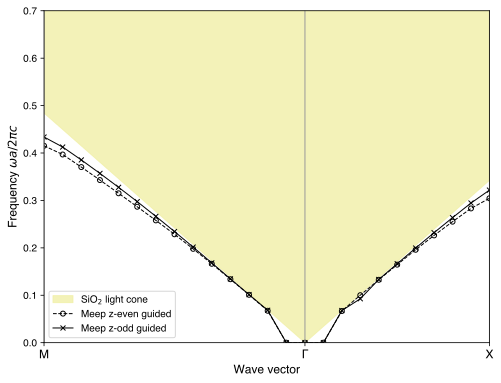

In [ ]:
def plot_meep_guided_modes(even_guided_freqs, odd_guided_freqs, ymax=0.7):
    """Plot the continuity-tracked guided branches below the silica light line.

    Every non-NaN entry in the input arrays corresponds to the single guided
    mode retained for that parity at the corresponding k point.
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    light_line = fdtd_path["k_parallel"] / n_clad

    ax.fill_between(
        fdtd_path["path_x"],
        light_line,
        ymax,
        color="#F0EFA6",
        alpha=0.8,
        label="SiO$_2$ light cone",
    )

    ax.plot(
        fdtd_path["path_x"],
        even_guided_freqs,
        "k--",
        lw=1.,
        marker="o",
        markerfacecolor="none",
        markersize=5,
        label="Meep z-even guided",
    )
    ax.plot(
        fdtd_path["path_x"],
        odd_guided_freqs,
        "k-",
        lw=1.,
        marker="x",
        markersize=5.0,
        label="Meep z-odd guided",
    )

    ax.set_xlim(fdtd_path["path_x"][0], fdtd_path["path_x"][-1])
    ax.set_ylim(0.0, ymax)
    ax.set_xticks(fdtd_path["tick_locs"])
    ax.set_xticklabels(fdtd_path["tick_labs"], size=12)
    ax.set_xlabel("Wave vector", size=12)
    ax.set_ylabel(r"Frequency $\omega a / 2\pi c$", size=12)
    for x in fdtd_path["tick_locs"]:
        ax.axvline(x, color="#999999", lw=1)
    ax.legend(loc="lower left")
    fig.tight_layout()


plot_meep_guided_modes(meep_even_guided_freqs, meep_odd_guided_freqs)

In [18]:
meep_even_guided_freqs, meep_odd_guided_freqs

(array([0.41522719, 0.39686499, 0.37034938, 0.34296761, 0.31504592,
        0.28665731, 0.25789578, 0.22857224, 0.19789228, 0.16636606,
        0.13383323, 0.1009572 , 0.06730037, 0.        , 0.        ,
        0.        , 0.06677265, 0.10014701, 0.13261867, 0.16453711,
        0.19592176, 0.22625561, 0.25519193, 0.28311542, 0.30448712]),
 array([0.43372178, 0.41255267, 0.38538723, 0.35694998, 0.32765582,
        0.2974472 , 0.26630694, 0.23433122, 0.20161033, 0.1682427 ,
        0.13457359, 0.10136095, 0.06837803, 0.        , 0.        ,
        0.        , 0.0677285 , 0.09259496, 0.13329293, 0.16655288,
        0.19957808, 0.23199731, 0.26368059, 0.29452554, 0.32175438]))

## What to take away

这一页 notebook 现在回答的是：

1. **MPB 可以复现与 `legume` 参数一致的 slab band plot，并能可靠给出光线以下的导模。**
2. **MPB 不能把光线以上的结果当作真实 leaky-mode bands 使用。** 证据是这些本征值对 `supercell_z` 很敏感，而且 MPB 只给实频率，不给辐射损耗。
3. **Meep 的 FDTD + Harminv 可以在同一几何上提取光线以上的离散共振点。**  
   默认示例已经能在 `M-Γ-X` 上提取到一部分对应 resonances；若要得到更完整、更平滑的 band diagram，需要：
   - 增加 `k` 点密度；
   - 按不同频段分窗口扫描；
   - 延长 `until_after_sources`；
   - 对可疑点检查场型，去除 PML / 拟合伪模。
